In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("project1_dataset_v2.csv")
df.head()

,client_id,age,gender,program,insurance_type,distance_miles,prior_no_shows,transportation_barrier,sms_reminder,no_show
0,100001,40.0,Female,Case Management,Self-Pay,8.481926,0,0,1,0
1,100002,32.0,Non-binary,Outpatient Therapy,Commercial,11.358938,1,0,1,0
2,100003,42.0,Non-binary,Substance Use,Self-Pay,24.660408,0,0,1,0
3,100004,52.0,Non-binary,Outpatient Therapy,Medicaid,28.573247,0,0,1,1
4,100005,31.0,Female,Substance Use,Self-Pay,19.935160,1,0,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   client_id               2500 non-null   int64  
 1   age                     2500 non-null   float64
 2   gender                  2500 non-null   object 
 3   program                 2500 non-null   object 
 4   insurance_type          2500 non-null   object 
 5   distance_miles          2500 non-null   float64
 6   prior_no_shows          2500 non-null   int64  
 7   transportation_barrier  2500 non-null   int64  
 8   sms_reminder            2500 non-null   int64  
 9   no_show                 2500 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 195.4+ KB


In [4]:
df.describe()

,client_id,age,distance_miles,prior_no_shows,transportation_barrier,sms_reminder,no_show
count,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000
mean,101250.50000,34.822800,15.383038,1.511200,0.248800,0.81200,0.454000
std,721.83216,10.992458,9.526004,1.237452,0.432404,0.39079,0.497979
min,100001.00000,18.000000,1.000000,0.000000,0.000000,0.00000,0.000000
25%,100625.75000,26.000000,8.025799,1.000000,0.000000,1.00000,0.000000
50%,101250.50000,34.000000,14.972099,1.000000,0.000000,1.00000,0.000000
75%,101875.25000,42.000000,22.015814,2.000000,0.000000,1.00000,1.000000
max,102500.00000,72.000000,48.981273,7.000000,1.000000,1.00000,1.000000


In [5]:
df['no_show'].value_counts(normalize=True)

no_show
0    0.546
1    0.454
Name: proportion, dtype: float64

In [15]:
df.columns

Index(['client_id', 'age', 'gender', 'program', 'insurance_type',
       'distance_miles', 'prior_no_shows', 'transportation_barrier',
       'sms_reminder', 'no_show'],
      dtype='object')

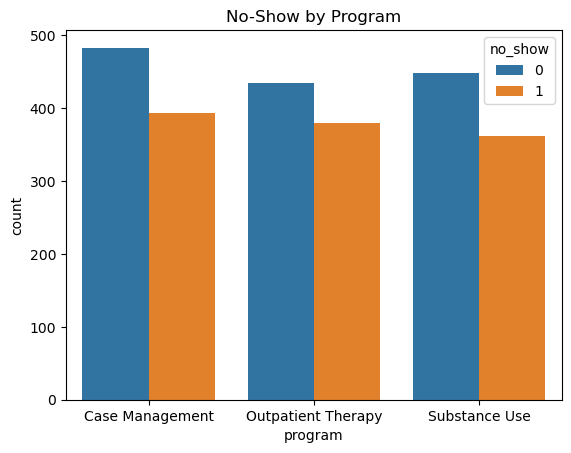

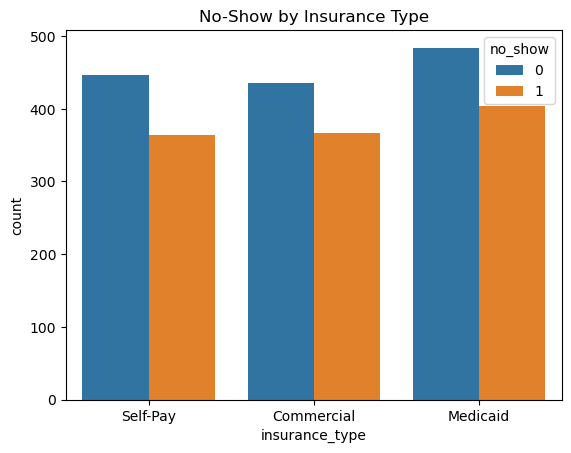

In [19]:
sns.countplot(x='program',hue='no_show',data=df)
plt.title("No-Show by Program")
plt.show()

sns.countplot(x='insurance_type', hue='no_show', data=df)
plt.title("No-Show by Insurance Type")
plt.show()

In [23]:
df_encoded = pd.get_dummies(df, drop_first=True)

x = df_encoded.drop('no_show',axis=1)
y = df_encoded['no_show']

In [29]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
)

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 1000)
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [31]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))

[[192  64]
 [136 108]]
              precision    recall  f1-score   support

           0       0.59      0.75      0.66       256
           1       0.63      0.44      0.52       244

    accuracy                           0.60       500
   macro avg       0.61      0.60      0.59       500
weighted avg       0.61      0.60      0.59       500



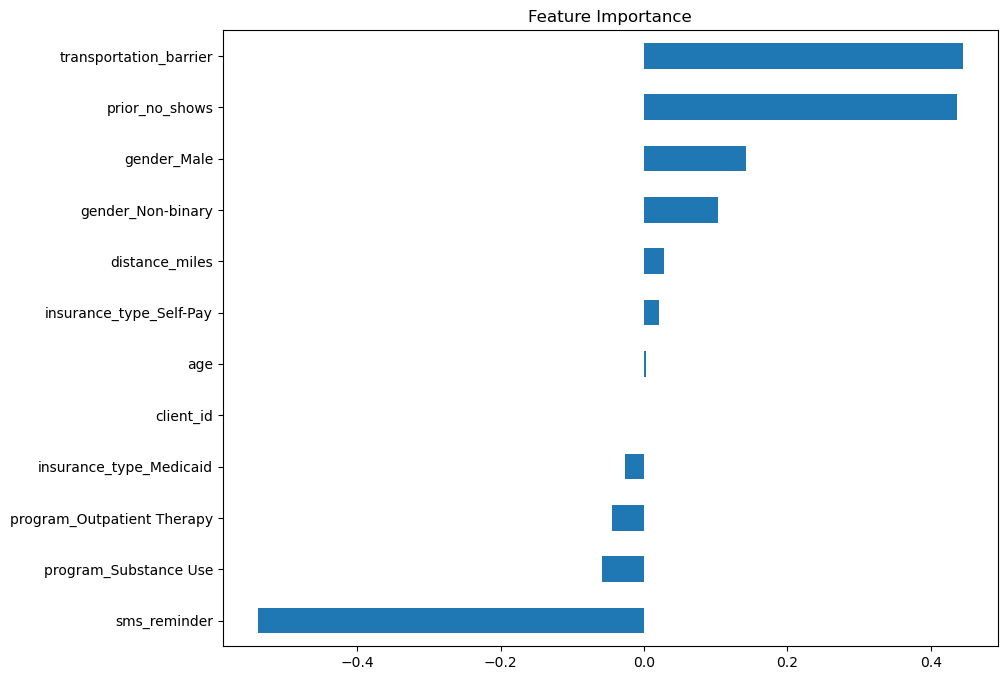

In [33]:
importance = pd.Series(model.coef_[0], index=x.columns)
importance.sort_values().plot(kind='barh',figsize=(10,8))
plt.title("Feature Importance")
plt.show()